# Classification of Polymarket Markets (538K)

**Goal**: label every Polymarket market into one of 15 project categories
(Sports, Esports, Crypto Price, Crypto Up/Down, Macroeconomy, US Politics,
Stocks/Finance, Cinema/TV, Press People, Social Media, Music, AI/Tech,
Geopolitics, Weather, Other).

**Method**:
1. Base regex from **Le (2026)**, *Decomposing Crowd Wisdom: Domain-Specific
   Calibration Dynamics in Prediction Markets* — arXiv:2602.19520 — MIT license,
   repo [`namanhz/prediction-market-calibration`](https://github.com/namanhz/prediction-market-calibration).
   The paper defines 4 Polymarket domains (Sports, Politics, Crypto, Finance)
   via regex on market titles.
2. **Sub-regex** to split each paper domain into our finer-grained categories
   (e.g. Politics → US Politics / Geopolitics).
3. **Custom regex** for categories absent from the paper (Esports, AI/Tech,
   Weather, Cinema/TV, Music, Press People, Social Media, Stocks tickers).
4. **Precedence** — highly-specific custom patterns run BEFORE the paper's
   broad regex to avoid collisions (e.g. "Trump nominates Fed chair" should be
   Macroeconomy, not US Politics).
5. **Fallback** to `Other` for unmatched titles.

**Validation**: we evaluate on `labeled_1500.csv` (1,500 hand-labeled markets)
with F1 macro, per-category precision/recall, and a confusion matrix.
Target: F1 macro ≥ 0.75.

**Environment**: Google Colab + BigQuery
(`polymarket-research-490517.polymarket.markets`).


## 1. Setup


In [1]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


## 2. Load Markets from BigQuery

We pull all 538K markets from the SII-WANGZJ dataset already loaded into
`polymarket-research-490517.polymarket.markets`.


In [2]:
# Colab-only: authenticate with Google
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="polymarket-research-490517")


In [3]:
query = """
SELECT id, question, slug, event_slug
FROM `polymarket-research-490517.polymarket.markets`
WHERE question IS NOT NULL
"""
all_markets = client.query(query).to_dataframe()
print(f"Loaded {len(all_markets):,} markets")
all_markets.head()


Loaded 607,561 markets


,id,question,slug,event_slug
0,1596322,Counter-Strike: CSDIILIT vs Bushido Wildcats (BO3) - ESL Challenger League Europe Cup #2 Playoffs,cs2-csdiil-bw-2026-03-16,cs2-csdiil-bw-2026-03-16
1,1596325,Counter-Strike: CSDIILIT vs Bushido Wildcats - Map 1 Winner,cs2-csdiil-bw-2026-03-16-game1,cs2-csdiil-bw-2026-03-16
2,1596328,Counter-Strike: CSDIILIT vs Bushido Wildcats - Map 2 Winner,cs2-csdiil-bw-2026-03-16-game2,cs2-csdiil-bw-2026-03-16
3,1507746,Map Handicap: CSDIILIT (-1.5) vs QUAZAR (+1.5),cs2-qua1-csdiil-2026-03-05-map-handicap-home-1pt5,cs2-qua1-csdiil-2026-03-05
4,1512233,Counter-Strike: CSDIILIT vs HEROIC Academy - Map 1 Winner,cs2-csdiil-heroa-2026-03-06-game1,cs2-csdiil-heroa-2026-03-06


## 3. Base Regex Patterns — Le (2026)

Verbatim from `src/classify.py` of
[namanhz/prediction-market-calibration](https://github.com/namanhz/prediction-market-calibration)
(MIT license). The paper defines 4 Polymarket domains; first match wins.


In [4]:
# Attribution: Le, N.A. (2026). "Decomposing Crowd Wisdom" (arXiv:2602.19520).
# Licensed under MIT. Source: github.com/namanhz/prediction-market-calibration

POLYMARKET_DOMAIN_PATTERNS = [
    (re.compile(
        r"(?i)\b("
        r"NFL|NBA|MLB|NHL|UFC|MMA|boxing|tennis|golf|F1|Formula 1|NASCAR|"
        r"Super Bowl|World Series|Stanley Cup|NCAA|March Madness|"
        r"Premier League|Champions League|La Liga|Serie A|Bundesliga|Ligue 1|"
        r"Europa League|World Cup|Copa America|MLS|WNBA|PGA|ATP|WTA|"
        r"Grand Slam|Wimbledon|US Open|Australian Open|French Open|"
        r"Ryder Cup|Olympics|Olympic|medal|"
        r"playoff|postseason|All[- ]Star|MVP|Cy Young|Heisman|"
        r"touchdown|home run|strikeout|rushing yards|rebound|assist|"
        r"point spread|moneyline|sack|interception|three-pointer|"
        r"batting average|ERA|free throw|penalty kick|"
        r"49ers|Packers|Chiefs|Eagles|Cowboys|Patriots|Dolphins|Bills|Ravens|Bengals|"
        r"Lakers|Celtics|Warriors|Bucks|Nuggets|Knicks|76ers|Heat|Nets|Suns|"
        r"Yankees|Dodgers|Braves|Astros|Mets|Red Sox|Cubs|Phillies|Padres|"
        r"Maple Leafs|Bruins|Rangers|Lightning|Avalanche|Panthers|Oilers|"
        r"Arsenal|Liverpool|Manchester|Chelsea|Barcelona|Real Madrid|Bayern|Juventus|"
        r"game \d|win.*series|win.*championship|win.*title"
        r")\b"
    ), "Sports"),
    (re.compile(
        r"(?i)\b("
        r"president|presidential|election|senate|congress|governor|"
        r"democrat|republican|GOP|Trump|Biden|Obama|"
        r"vote|ballot|primary|caucus|nominee|nomination|"
        r"Supreme Court|executive order|impeach|filibuster|debt ceiling|"
        r"shutdown|electoral college|swing state|poll|approval rating|"
        r"cabinet|attorney general|secretary of state|Speaker|majority leader|"
        r"veto|legislation|midterm|runoff|recall|referendum|"
        r"RFK|DeSantis|Haley|Ramaswamy|Newsom|Pence|Kamala|Harris|"
        r"McConnell|Pelosi|AOC|Schumer|Vance|Vivek|"
        r"indictment|classified documents|"
        r"NATO|Ukraine|Russia|China.*Taiwan|Israel|Iran|sanction|"
        r"TikTok.*ban|government.*ban|Congress.*pass|"
        r"federal|POTUS|White House|inaugurat"
        r")\b"
    ), "Politics"),
    (re.compile(
        r"(?i)\b("
        r"Bitcoin|BTC|Ethereum|ETH|crypto|Solana|SOL|Dogecoin|DOGE|XRP|"
        r"token|blockchain|DeFi|altcoin|stablecoin|USDC|USDT|Tether|"
        r"Binance|Coinbase|FTX|SBF|halving|mining|NFT|airdrop|"
        r"memecoin|Pepe|Shiba|TVL|DEX|CEX|"
        r"Bitcoin ETF|Ethereum ETF|spot ETF|"
        r"Layer 2|rollup|zkSync|Arbitrum|Polygon|Avalanche|Cardano|ADA|"
        r"Ripple|Litecoin|Polkadot|Chainlink|Uniswap"
        r")\b"
    ), "Crypto"),
    (re.compile(
        r"(?i)\b("
        r"S&P|S&P 500|NASDAQ|Dow Jones|Russell 2000|stock|"
        r"Fed |Federal Reserve|interest rate|rate cut|rate hike|FOMC|"
        r"CPI|inflation|GDP|recession|tariff|"
        r"IPO|treasury|yield curve|bond|"
        r"unemployment|jobs report|nonfarm payroll|non-farm payroll|PCE|PPI|"
        r"housing starts|retail sales|consumer confidence|"
        r"earnings|revenue|market cap|PE ratio|"
        r"merger|acquisition|bankruptcy|credit rating|"
        r"oil price|gold price|commodity|forex|"
        r"quantitative|balance sheet|FDIC|"
        r"trade deficit|budget|fiscal|monetary policy"
        r")\b"
    ), "Finance"),
]
print(f"Paper patterns loaded: {len(POLYMARKET_DOMAIN_PATTERNS)} domains")


Paper patterns loaded: 4 domains


## 4. Extended Patterns — Custom Categories & Sub-splits

Error analysis on `labeled_1500.csv` drove several precedence decisions:

- **Macroeconomy must run BEFORE Politics** — questions like
  "Trump nominates Fed chair", "Trump tariffs", "US Government shutdown" are
  tagged Macroeconomy by humans even though they contain Trump/government.
- **Stocks tickers must run BEFORE AI/Tech** — "NVIDIA (NVDA) earnings",
  "Tesla (TSLA) close above $X" are Stocks/Finance, not AI/Tech.
- **Esports must run BEFORE Sports** — esports markets use generic terms like
  "Game 1", "Total Kills", "First Blood".
- **Sports has a custom fallback** — paper's Sports regex misses "X vs. Y"
  matchups and "Spread: Team (-N)" lines.
- **Press People** needs to catch "TIME Person of the Year", "richest person",
  "Person [A-Z]" placeholders.
- **Geopolitics** needs explicit country names (Romania, Poland, Germany…) to
  beat paper's Politics default to "US Politics".


In [5]:
# ── 1. Esports (before paper's Sports) ──
ESPORTS_PATTERN = re.compile(
    r"(?i)\b("
    r"League of Legends|LoL Worlds|LCS|LEC|LPL|LCK|LoL\b|"
    r"Counter[- ]Strike|CS:GO|CS2|CSGO|IEM|ESL Pro League|"
    r"Dota 2|Dota\b|The International|TI\d|"
    r"Valorant|VCT|"
    r"Rainbow Six Siege|R6\b|"
    r"Rocket League|RLCS|"
    r"Overwatch League|OWL\b|"
    r"Fortnite|Apex Legends|Warzone|Call of Duty League|CDL\b|"
    r"esports|e-sports|Hearthstone|Starcraft|PUBG|"
    r"Faker|s1mple|ZywOo|Team Liquid|"
    r"Total Kills.*Game|First Blood.*Game|Map \d Winner|"
    r"Kills Over/Under"
    r")\b"
)

# ── 2. Stocks tickers (before AI/Tech to reclaim NVDA/TSLA) ──
STOCKS_TICKER_PATTERN = re.compile(
    r"(?i)(?:"
    r"\((NVDA|TSLA|AAPL|MSFT|GOOG|GOOGL|AMZN|META|NFLX|AMD|INTC|QQQ|SPY)\)|"
    r"\b(NVIDIA|Tesla|Apple|Microsoft|Google|Amazon|Meta Platforms|Netflix|AMD|Intel)\s+\((NVDA|TSLA|AAPL|MSFT|GOOG|GOOGL|AMZN|META|NFLX|AMD|INTC)\)|"
    r"\b(close|finish|end|hit|above|below)\s+(?:week|end|\$|the\s+day).*\$\d|"
    r"\bquarterly\s+earnings\b|"
    r"\bmarket\s+cap\s+(?:be|at)\s+(?:between\s+)?\$"
    r")"
)

# ── 3. Macroeconomy (before Politics — Fed/tariff/shutdown regardless of Trump) ──
MACRO_PATTERN = re.compile(
    r"(?i)\b("
    r"Fed |Federal Reserve|FOMC|Jerome Powell|Powell|Fed chair|"
    r"interest rate|rate (cut|hike|decision|pause)|basis point|bps\b|"
    r"CPI|inflation|deflation|core PCE|PCE|PPI|"
    r"GDP|recession|economic growth|"
    r"unemployment|jobs report|nonfarm payroll|non-farm payroll|NFP\b|JOLTS|"
    r"tariff|trade war|trade deal|"
    r"housing starts|retail sales|consumer confidence|ISM|PMI|"
    r"treasury (yield|bond)|yield curve|"
    r"quantitative (tightening|easing)|QT\b|QE\b|balance sheet|"
    r"fiscal|monetary policy|debt ceiling|government shutdown|shutdown"
    r")\b"
)

# ── 4. AI / Tech ──
AI_TECH_PATTERN = re.compile(
    r"(?i)("
    r"\bOpenAI\b|\bChatGPT\b|\bGPT[- ]?\d|\bGPT[- ]?5\b|\bClaude\b|\bAnthropic\b|\bGemini\b|\bLlama\b|"
    r"\bDeepSeek\b|\bMistral\b|\bDALL[- ]?E\b|\bSora\b|\bMidjourney\b|Stable Diffusion|"
    r"\bAGI\b|\bASI\b|artificial general intelligence|superintelligence|"
    r"\bbest AI model\b|\btop AI model\b|\bAI model\b|\bxAI\b|\bGrok\b|Grokipedia|"
    r"\bPerplexity\b|\bMoonshot\b|\bZ\.ai\b|\bAnysphere\b|\bCursor AI\b|"
    r"Apple Vision|Vision Pro|iPhone \d|Pixel \d|"
    r"SpaceX|Starlink|Starship|Neuralink|"
    r"Apple release|Google release|Microsoft release|"
    r"Quest \d|Humanoid robot|\brobot\b|"
    r"self[- ]driving|autonomous vehicle|Waymo|Cruise|Robotaxi|"
    r"H100|H200|chip shortage|semiconductor|TSMC"
    r")"
)

# ── 5. Politics sub-split: Geopolitics vs US Politics ──
GEOPOLITICS_PATTERN = re.compile(
    r"(?i)\b("
    # Russia/Ukraine
    r"NATO|Ukraine|Russia|Russian|Putin|Zelensky|"
    # China/Taiwan
    r"China|Chinese|Taiwan|Xi Jinping|Hong Kong|"
    # Middle East
    r"Israel|Israeli|Gaza|Palestine|Palestinian|Hamas|Netanyahu|Hezbollah|"
    r"Iran|Iranian|Khamenei|Saudi Arabia|MBS|Yemen|Houthi|"
    r"Lebanon|Syria|Assad|"
    # Korea
    r"North Korea|Kim Jong|South Korea|Korean|"
    # Europe
    r"European Union|EU\b|Brexit|UK\b|United Kingdom|"
    r"Germany|German|Merz|Scholz|Merkel|"
    r"France|French|Macron|"
    r"Italy|Italian|Meloni|"
    r"Spain|Spanish|Sánchez|"
    r"Portugal|Portuguese|"
    r"Netherlands|Dutch|Volt Netherlands|"
    r"Poland|Polish|Trzaskowski|Zandberg|"
    r"Romania|Romanian|Nicușor Dan|George Simion|Geoană|"
    r"Ireland|Irish|Fitzgerald|O'Reilly|"
    r"Greece|Greek|"
    # Other
    r"Venezuela|Maduro|Cuba|Argentina|Milei|Mexico|AMLO|Sheinbaum|Brazil|Bolsonaro|Lula|"
    r"Chile|Chilean|Matthei|Peru|Colombia|Petro|Ecuador|"
    r"India|Modi|Pakistan|Afghanistan|Taliban|Bangladesh|"
    r"Turkey|Turkish|Erdogan|"
    r"Canada|Trudeau|Carney|Poilievre|"
    r"Australia|Australian|New Zealand|"
    r"Japan|Japanese|Ishiba|Kishida|"
    r"Philippines|Philippine|Lakas|"
    r"Nigeria|Ethiopia|Kenya|South Africa|Ramaphosa|African Union|"
    # International institutions / concepts
    r"OPEC|G7\b|G20\b|UN\b|United Nations|WHO|IMF|"
    r"war|invasion|ceasefire|peace deal|hostage|"
    r"sanction|embargo|"
    r"coup|regime|diplomat|treaty|summit|"
    r"foreign|international|global"
    r")\b"
)

# ── 6. Crypto sub-split: Up/Down vs Price ──
CRYPTO_UP_DOWN_PATTERN = re.compile(
    r"(?i)\b("
    r"up or down|higher or lower|go up|go down|"
    r"close (above|below|higher|lower)|"
    r"end (above|below|higher|lower|the day|the week|the month)|"
    r"green day|red day|"
    r"up today|down today|up this week|down this week|"
    r"gain today|lose today|pump|dump"
    r")\b"
)

# ── 7. Custom Sports fallback (X vs. Y, Spread:, conference matchups) ──
SPORTS_FALLBACK_PATTERN = re.compile(
    r"(?i)("
    r"\bvs\.?\s+[A-Z]|"                                    # "Kings vs. Utah"
    r"^Spread:|^Total:|^Moneyline:|^Over/Under:|"          # betting lines
    r"\b(win|lose) (the )?(Eastern|Western) Conference\b|"
    r"Men's Final|Women's Final|"
    r"\bHornets\b|\bPistons\b|\bBulls\b|\bTimberwolves\b|\bJazz\b|"
    r"\bKings\b|\bRockets\b|\bMavericks\b|\bWizards\b|\bPacers\b|"
    r"\bThunder\b|\bCavaliers\b|\bTrail Blazers\b|\bHawks\b|\bStars\b|\bSharks\b|"
    r"\bOrioles\b|\bGuardians\b|\bWolves\b|\bMagic\b|\bRaptors\b|\bPelicans\b|\bSpurs\b|"
    r"\bRockies\b|\bPirates\b|\bMariners\b|\bRays\b|\bBrewers\b|\bReds\b|\bMarlins\b|"
    r"\bSabres\b|\bFlyers\b|\bWild\b|\bDucks\b|\bFlames\b|\bJets\b|\bBlues\b|\bStars\b|"
    r"\bBroncos\b|\bTexans\b|\bRams\b|\bSaints\b|\bFalcons\b|\bLions\b|\bJaguars\b|"
    r"\bTitans\b|\bColts\b|\bBrowns\b|\bSteelers\b|\bSeahawks\b|\bVikings\b|\bGiants\b|"
    r"Ole Miss|Tulane|Memphis|Arizona State|North Texas"
    r")"
)

# ── 8. Weather ──
WEATHER_PATTERN = re.compile(
    r"(?i)\b("
    r"hurricane|tropical storm|tornado|cyclone|typhoon|"
    r"snow|snowfall|blizzard|"
    r"heat wave|heatwave|cold snap|"
    r"temperature|degrees Fahrenheit|degrees Celsius|"
    r"earthquake|magnitude|Richter|"
    r"wildfire|drought|flood|"
    r"rainfall|precipitation|"
    r"category \d hurricane|Saffir[- ]Simpson|"
    r"NOAA|NWS|hurricane season|Atlantic season|"
    r"El Niño|La Niña|climate change"
    r")\b"
)

# ── 9. Music ──
MUSIC_PATTERN = re.compile(
    r"(?i)\b("
    r"Grammy|Grammys|AMA|American Music Award|MTV VMA|VMAs|"
    r"Billboard|Hot 100|top of the charts|#1 song|number one single|"
    r"Spotify|Apple Music|streams|streaming|platinum|gold certified|"
    r"album|song|single|track|music video|EP release|"
    r"Taylor Swift|Beyoncé|Drake|Kanye|Kendrick Lamar|The Weeknd|"
    r"Rihanna|Bad Bunny|Bruno Mars|Eminem|Lady Gaga|Adele|Ed Sheeran|"
    r"Ariana Grande|Billie Eilish|Dua Lipa|Olivia Rodrigo|Sabrina Carpenter|"
    r"Coachella|Glastonbury|Lollapalooza|Tomorrowland|"
    r"concert|tour|music festival|record label|RIAA"
    r")\b"
)

# ── 10. Cinema / TV ──
CINEMA_TV_PATTERN = re.compile(
    r"(?i)\b("
    r"Oscar|Oscars|Academy Award|Best Picture|Best Actor|Best Actress|Best Director|"
    r"Emmy|Emmys|Golden Globe|BAFTA|Cannes|Sundance|SAG Awards|"
    r"box office|opening weekend|gross|Rotten Tomatoes|IMDb|"
    r"Netflix|Disney\+|HBO|Hulu|Amazon Prime|Apple TV|Paramount\+|Peacock|"
    r"Marvel|MCU|DC Comics|Star Wars|Harry Potter|James Bond|"
    r"season \d|episode|finale|spin[- ]off|reboot|sequel|prequel|trailer|"
    r"Game of Thrones|Stranger Things|Succession|House of the Dragon|The Last of Us|"
    r"Squid Game|The Crown|Bridgerton|The Bear|Severance|"
    r"\bmovie\b|\bfilm\b|TV show|TV series|streaming series|"
    r"Barbie|Oppenheimer|Avatar|Dune|Deadpool|Wicked"
    r")\b"
)

# ── 11. Social Media ──
SOCIAL_MEDIA_PATTERN = re.compile(
    r"(?i)\b("
    r"TikTok|Twitter|Tweet\b|X\.com|Instagram|Threads|Snapchat|"
    r"Facebook|Meta platform|WhatsApp|Telegram|Discord|YouTube|"
    r"subscribers|followers|views|viral|trending|hashtag|"
    r"influencer|creator economy|MrBeast|PewDiePie|KSI|Logan Paul|Jake Paul|"
    r"Elon.*(tweet|post|X)|Musk.*(tweet|post|X)|"
    r"Bluesky|Mastodon|Reddit|Twitch|Kick streamer"
    r")\b"
)

# ── 12. Press People (expanded — TIME Person, richest person, Person [A-Z]) ──
PRESS_PEOPLE_PATTERN = re.compile(
    r"(?i)("
    # TIME Person of the Year (applied if not AI/Tech)
    r"\bTIME'?s? Person of the Year\b|Time \d{4} person of the year|person of the year shortlist|"
    # "Richest person" questions (Forbes-style)
    r"\b(richest|3rd richest|2nd richest|wealthiest) person\b|"
    # Anonymized "Person A/B/C..." placeholders
    r"\bPerson [A-Z]\b|"
    # Celebrities / tabloids
    r"\bKardashian\b|\bJenner\b|\bKanye\b|Kim K\b|\bKylie\b|\bKendall\b|"
    r"Drake vs|Kendrick vs|"
    r"divorce|engaged|engagement|wedding|\bmarry\b|\bmarriage\b|"
    r"\bbaby\b|\bpregnant\b|\bpregnancy\b|gender reveal|"
    r"Meghan Markle|Prince Harry|\bRoyal\b|King Charles|\bQueen\b|Buckingham|"
    r"\bDiddy\b|P Diddy|Sean Combs|R Kelly|Weinstein|Epstein|"
    r"\bbreakup\b|cheating|\baffair\b|\bdating\b|"
    r"Page Six|\bTMZ\b|tabloid|\bcelebrity\b|"
    r"Zuckerberg.*fight|cage match|"
    r"Johnny Depp|Amber Heard|trial verdict|"
    r"pass the bar exam|bar exam"
    r")"
)

print("Extended patterns loaded.")


Extended patterns loaded.


### Main classifier (priority-ordered)

**Priority** (first match wins):
1. Esports
2. Stocks ticker (before AI/Tech — NVDA/TSLA go to Stocks/Finance)
3. Macroeconomy (before Politics — Trump+Fed goes to Macroeconomy)
4. AI/Tech
5. Paper's Sports → Sports
6. Paper's Politics → Geopolitics vs US Politics
7. Paper's Crypto → Crypto Up/Down vs Crypto Price
8. Paper's Finance → Stocks/Finance (Macro already handled above)
9. Custom Sports fallback (X vs. Y, Spread:, team names missed by paper)
10. Weather, Music, Cinema/TV, Social Media, Press People
11. Other


In [6]:
def classify(title: str) -> str:
    """Return one of 15 target categories. First-match wins."""
    if not title or not isinstance(title, str):
        return "Other"
    t = title

    # 1. Esports (before Sports)
    if ESPORTS_PATTERN.search(t):
        return "Esports"

    # 2. Stocks ticker (before AI/Tech so NVDA/TSLA go to Stocks)
    if STOCKS_TICKER_PATTERN.search(t):
        return "Stocks/Finance"

    # 3. Macroeconomy (before Politics — reclaims Trump+Fed/tariff/shutdown)
    if MACRO_PATTERN.search(t):
        return "Macroeconomy"

    # 4. AI/Tech
    if AI_TECH_PATTERN.search(t):
        return "AI/Tech"

    # 5-8. Paper's 4 domains with sub-splits
    for pattern, domain in POLYMARKET_DOMAIN_PATTERNS:
        if pattern.search(t):
            if domain == "Sports":
                return "Sports"
            if domain == "Politics":
                return "Geopolitics" if GEOPOLITICS_PATTERN.search(t) else "US Politics"
            if domain == "Crypto":
                return "Crypto Up/Down" if CRYPTO_UP_DOWN_PATTERN.search(t) else "Crypto Price"
            if domain == "Finance":
                # Macroeconomy already handled in step 3
                return "Stocks/Finance"

    # 9. Custom Sports fallback (paper misses "X vs. Y", "Spread:", team names)
    if SPORTS_FALLBACK_PATTERN.search(t):
        return "Sports"

    # 10. Fallback custom categories
    if WEATHER_PATTERN.search(t):
        return "Weather"
    if MUSIC_PATTERN.search(t):
        return "Music"
    if CINEMA_TV_PATTERN.search(t):
        return "Cinema/TV"
    if SOCIAL_MEDIA_PATTERN.search(t):
        return "Social Media"
    if PRESS_PEOPLE_PATTERN.search(t):
        return "Press People"

    return "Other"


# Quick smoke test
for q in [
    "Will Bitcoin reach $100K by end of 2025?",
    "Will BTC close higher or lower on Jan 15?",
    "Will Trump win Michigan in 2024?",
    "Ukraine-Russia war ends by Q1 2025?",
    "Will the Fed cut rates in March 2025?",
    "Will Trump nominate Scott Bessent as the next Fed chair?",
    "Will NVIDIA (NVDA) beat quarterly earnings?",
    "Will Tesla (TSLA) close above $450 end of March?",
    "Will T1 win LoL Worlds 2024?",
    "Total Kills Over/Under 31.5 in Game 3?",
    "Will ChatGPT-5 launch before July 2025?",
    "Will xAI have the top AI model on April 30?",
    "Hurricane Milton hits Florida as Cat 4?",
    "Oscar Best Picture 2025?",
    "Will Taylor Swift release a new album in 2025?",
    "Will Elon Musk tweet 100K times in 2025?",
    "Kim Kardashian and Kanye divorce finalized?",
    "Will LeBron James be TIME's Person of the Year for 2025?",
    "Will Jensen Huang be 3rd richest person on March 31?",
    "Kings vs. Utah",
    "Spread: Thunder (-14.5)",
    "Will Nicușor Dan win the Romanian presidential election?",
    "Random unlabelable question about nothing",
]:
    print(f"  [{classify(q)}] {q}")


  [Crypto Price] Will Bitcoin reach $100K by end of 2025?
  [Crypto Up/Down] Will BTC close higher or lower on Jan 15?
  [US Politics] Will Trump win Michigan in 2024?
  [Geopolitics] Ukraine-Russia war ends by Q1 2025?
  [Macroeconomy] Will the Fed cut rates in March 2025?
  [Macroeconomy] Will Trump nominate Scott Bessent as the next Fed chair?
  [Stocks/Finance] Will NVIDIA (NVDA) beat quarterly earnings?
  [Stocks/Finance] Will Tesla (TSLA) close above $450 end of March?
  [Esports] Will T1 win LoL Worlds 2024?
  [Esports] Total Kills Over/Under 31.5 in Game 3?
  [AI/Tech] Will ChatGPT-5 launch before July 2025?
  [AI/Tech] Will xAI have the top AI model on April 30?
  [Weather] Hurricane Milton hits Florida as Cat 4?
  [Cinema/TV] Oscar Best Picture 2025?
  [Music] Will Taylor Swift release a new album in 2025?
  [Social Media] Will Elon Musk tweet 100K times in 2025?
  [Music] Kim Kardashian and Kanye divorce finalized?
  [Press People] Will LeBron James be TIME's Person of the Y

## 5. Validate on `labeled_1500.csv`

Upload `labeled_1500.csv` (1,500 hand-labeled markets) to compute F1 macro and
a confusion matrix — this tells us whether the rules agree with human judgment.


In [7]:
from google.colab import files
uploaded = files.upload()  # select labeled_1500.csv

labeled = pd.read_csv("labeled_1500.csv")
print(f"Loaded {len(labeled)} hand-labeled markets")
print(labeled["label"].value_counts())


Saving labeled_1500.csv to labeled_1500.csv
Loaded 1500 hand-labeled markets
label
Sports            418
Geopolitics       104
US Politics       100
Social Media       95
Stocks/Finance     93
Crypto Up/Down     91
Cinema/TV          84
Macroeconomy       81
AI/Tech            81
Other              77
Crypto Price       73
Press People       60
Music              50
Esports            48
Weather            45
Name: count, dtype: int64


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

labeled["predicted"] = labeled["question"].apply(classify)

f1 = f1_score(labeled["label"], labeled["predicted"], average="macro")
acc = (labeled["label"] == labeled["predicted"]).mean()
print(f"Accuracy : {acc:.3f}")
print(f"F1 macro : {f1:.3f}")
print()
print(classification_report(labeled["label"], labeled["predicted"], zero_division=0))


Accuracy : 0.781
F1 macro : 0.806

                precision    recall  f1-score   support

       AI/Tech       0.94      0.91      0.93        81
     Cinema/TV       0.97      0.88      0.93        84
  Crypto Price       0.88      0.78      0.83        73
Crypto Up/Down       0.99      0.77      0.86        91
       Esports       1.00      0.79      0.88        48
   Geopolitics       0.82      0.56      0.66       104
  Macroeconomy       0.73      0.91      0.81        81
         Music       0.81      0.76      0.78        50
         Other       0.17      0.45      0.25        77
  Press People       0.70      0.97      0.81        60
  Social Media       1.00      0.98      0.99        95
        Sports       0.98      0.72      0.83       418
Stocks/Finance       0.86      0.75      0.80        93
   US Politics       0.63      0.89      0.74       100
       Weather       1.00      0.98      0.99        45

      accuracy                           0.78      1500
     macro 

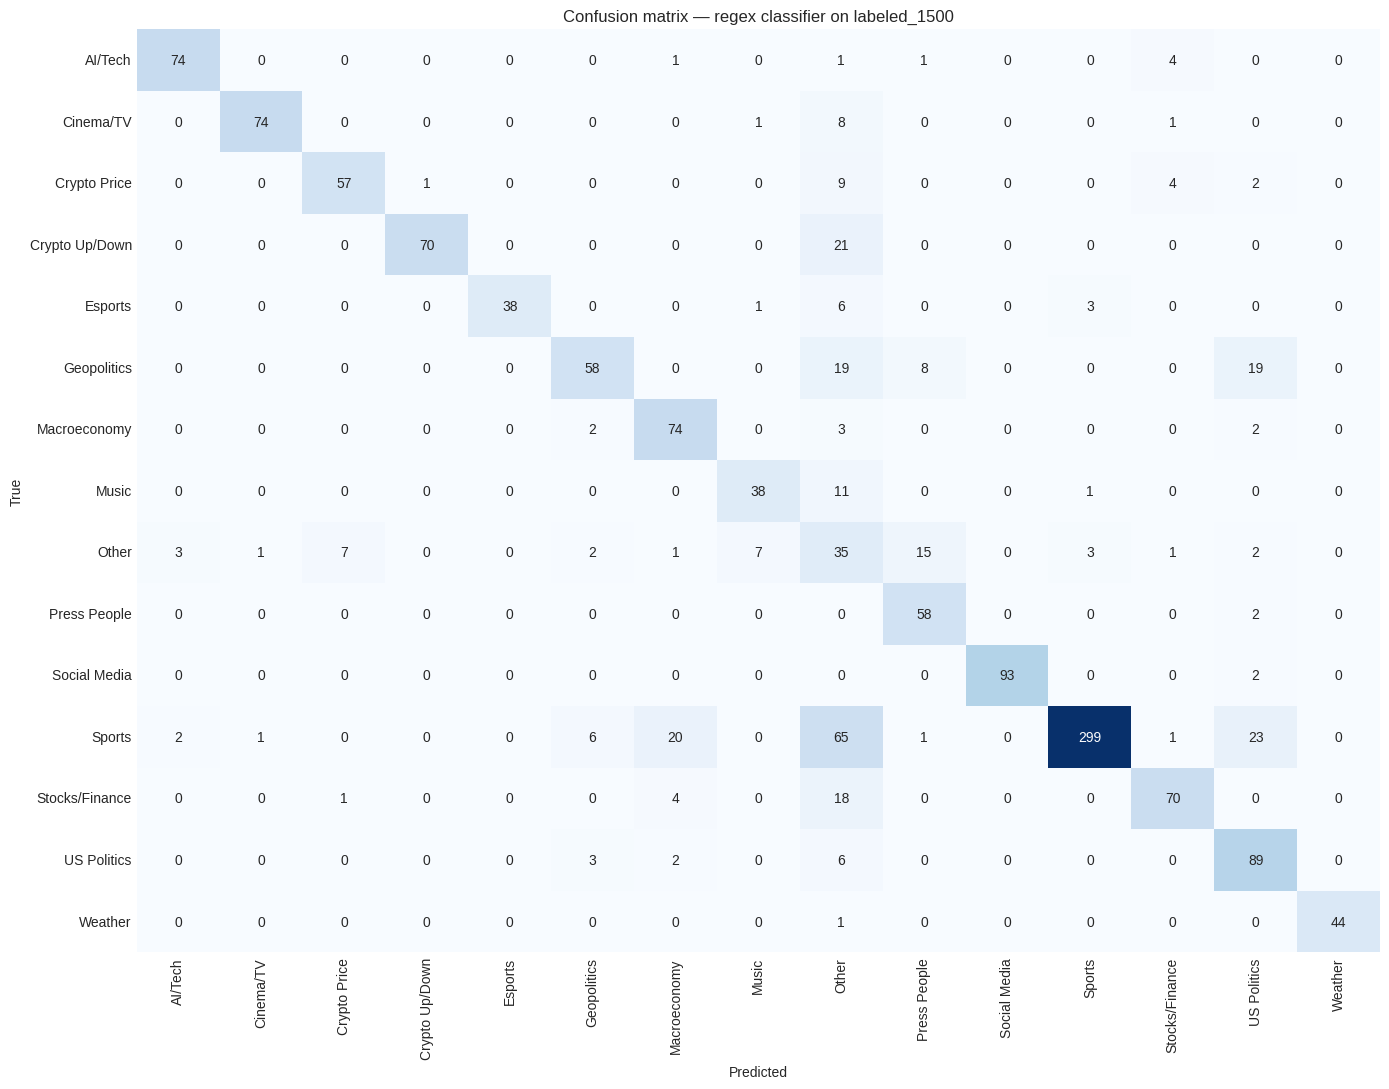

In [9]:
# Confusion matrix
cats = sorted(set(labeled["label"].unique()) | set(labeled["predicted"].unique()))
cm = confusion_matrix(labeled["label"], labeled["predicted"], labels=cats)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=cats, yticklabels=cats, cbar=False, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix — regex classifier on labeled_1500")
plt.tight_layout()
plt.show()


In [10]:
# Error analysis: 5 misclassified examples per true category
errors = labeled[labeled["label"] != labeled["predicted"]]
print(f"Errors: {len(errors)}/{len(labeled)} ({100*len(errors)/len(labeled):.1f}%)\n")

for cat in sorted(labeled["label"].unique()):
    cat_errors = errors[errors["label"] == cat].head(5)
    if len(cat_errors):
        print(f"=== True: {cat} — {len(errors[errors['label']==cat])} errors ===")
        for _, r in cat_errors.iterrows():
            print(f"  predicted={r['predicted']!r:20s} | {r['question'][:90]}")
        print()


Errors: 329/1500 (21.9%)

=== True: AI/Tech — 7 errors ===
  predicted='Press People'       | Will Artificial Intelligence be TIME's Person of the Year for 2025?
  predicted='Stocks/Finance'     | Will OpenAI’s market cap be between $1T and $1.25T at market close on IPO day?
  predicted='Stocks/Finance'     | Will OpenAI’s market cap be $1.5T or greater at market close on IPO day by December 31, 20
  predicted='Stocks/Finance'     | Will OpenAI’s market cap be between $1.25T and $1.5T at market close on IPO day?
  predicted='Other'              | AI data center moratorium passed before 2027?

=== True: Cinema/TV — 10 errors ===
  predicted='Other'              | Will Contestant C win The Bachelorette Season 22?
  predicted='Other'              | Will Quintavius "Q" Burdette win Survivor Season 50?
  predicted='Other'              | Will Endless Cookie be nominated for Best Documentary Feature at the 98th Academy Awards?
  predicted='Music'              | Will Song K win Best Original S

## 6. Apply to All 538K Markets

If F1 macro on the labeled set is satisfactory (target: ≥ 0.75), we apply
the classifier to the full corpus.


In [11]:
%time all_markets["predicted_label"] = all_markets["question"].apply(classify)

counts = all_markets["predicted_label"].value_counts()
print(counts)
print(f"\nTotal: {len(all_markets):,}")
print(f"'Other' share: {100*counts.get('Other', 0)/len(all_markets):.1f}%")


CPU times: user 1min 34s, sys: 68.3 ms, total: 1min 34s
Wall time: 1min 37s
predicted_label
Sports            199651
Crypto Up/Down    174185
Other              90290
Esports            40754
Crypto Price       38550
US Politics        15943
Weather            14922
Stocks/Finance      9952
Geopolitics         6028
Social Media        4710
Cinema/TV           4624
Macroeconomy        2730
Music               2579
AI/Tech             1749
Press People         894
Name: count, dtype: int64

Total: 607,561
'Other' share: 14.9%


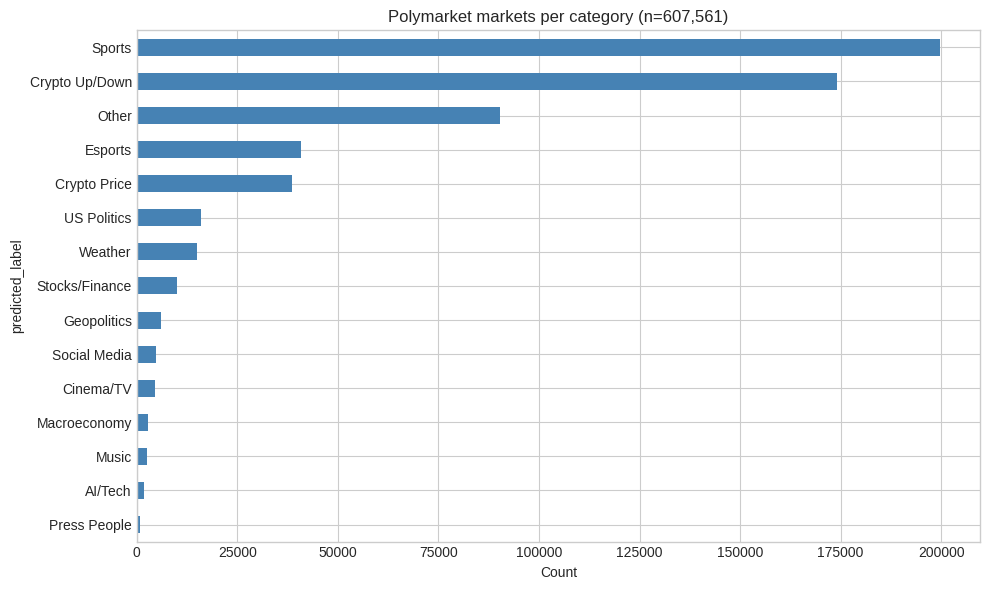

In [12]:
# Bar chart of distribution
fig, ax = plt.subplots(figsize=(10, 6))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Polymarket markets per category (n={len(all_markets):,})")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Upload to BigQuery

Write the classified table back to BigQuery for later joins with trades and
financial data.


In [13]:
table_id = "polymarket-research-490517.polymarket.markets_classified"

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
job = client.load_table_from_dataframe(
    all_markets[["id", "slug", "event_slug", "question", "predicted_label"]],
    table_id,
    job_config=job_config,
)
job.result()
print(f"Uploaded {len(all_markets):,} rows to {table_id}")


Uploaded 607,561 rows to polymarket-research-490517.polymarket.markets_classified


In [14]:
# Backup CSV (optional)
all_markets.to_csv("markets_classified.csv", index=False)
files.download("markets_classified.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Next Steps

If F1 macro is below target, iterate on the sub-regex in **section 4**:
- Inspect the error-analysis output (section 5 last cell) to see which
  categories get confused.
- Add keywords or tighten patterns that over/under-match.
- Re-run section 5, then section 6.

Once satisfied, the `markets_classified` BigQuery table is ready for phase 5b
(alignment with financial data) and phase 5c (sentiment × market correlation).

**Attribution**: base regex for Sports / Politics / Crypto / Finance from
Le, N.A. (2026). *Decomposing Crowd Wisdom: Domain-Specific Calibration
Dynamics in Prediction Markets.* arXiv:2602.19520. MIT license,
[github.com/namanhz/prediction-market-calibration](https://github.com/namanhz/prediction-market-calibration).
